# GDELT sector × region media index

Builds the weekly **sector × region news index** used as a scoring-time *gate*, and nothing else.

## Scope

This notebook covers only the BigQuery pull and the sector × region machinery:

1. BigQuery client and config
2. Sector taxonomy — the 21 Companies House SIC sections
3. The sector × region weekly index (`tone_z`, `vol_z`), cached to Parquet
4. Company postcode → region, the join key on the company side
5. The weekly sector gate used at scoring time

## How the media index is actually used

It is used at scoring time to **sequence** an already-qualified lead list: which sectors an RM works
first this week. Measured on 464 historical conversions, a cell's own high-volume weeks carry ~17%
more conversions than its own quiet weeks (z = 1.67, not significant), and `tone_z` shows no effect
at all (1.00× lift). So the gate uses **`vol_z` only**, as a soft re-rank rather than a hard filter,
and is honestly a workload-sequencing and conversation-hook device — not a demonstrated uplift.

## 1 · BigQuery client and config

In [8]:
# --- BigQuery hybrid route: imports + client -------------------------------
# Run once:  pip install google-cloud-bigquery db-dtypes pandas matplotlib
# --- portable paths --------------------------------------------------------
# GDELT_CACHE is the Parquet cache folder, resolved from paths.py rather than
# from the working directory. This matters more here than anywhere else: if the
# cache folder resolves wrongly, USE_CACHE finds no file and the next cell
# launches a ~350 GB BigQuery scan against the 1 TB/month free tier.
import sys
from pathlib import Path
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "paths.py").is_file()), None)
if ROOT is None:
    raise RuntimeError(
        "Cannot find paths.py in any parent of "
        f"{Path.cwd()} — run this notebook from inside the project folder.")
sys.path.insert(0, str(ROOT))
from paths import GDELT_CACHE, MEDIA_INDEX

import datetime as dt
import re
import pandas as pd
import matplotlib.pyplot as plt
from google.cloud import bigquery

PROJECT = "lloyds-gdelt"   # <-- set your GCP project (billing must be enabled)

try:
    client = bigquery.Client(project=PROJECT) # opens an authenticated session tied to your project.
    print("BigQuery client ready for project:", client.project)
except Exception as e:
    client = None
    print("BigQuery client NOT ready — finish the setup steps in the markdown above.\n ",
          type(e).__name__, ":", e)

BigQuery client ready for project: lloyds-gdelt


In [9]:
# --- Config + helpers ------------------------------------------------------
GKG = "`gdelt-bq.gdeltv2.gkg_partitioned`"   # partitioned table = cheap date pruning

# Run window. For a weekly job this is "the last 7 days".
END_D   = dt.date.today()
START_D = END_D - dt.timedelta(days=7)

# Theme approximation of your free-text intent ("construction" + "funding").
# Each inner list = OR (a theme NAME contains any token); the groups are AND-ed.
# Refine these tokens against LOOKUP-GKGTHEMES.TXT, then spot-check matching URLs.
THEME_FILTERS = [
    ["INFORMATION", "TECHNOLOGY", "DIGITAL"],
    ["FUND", "SUBSID", "FINANC", "INVEST", "GRANT"],
]

# UK city -> region rollup (extend freely). Unmapped cities -> "Other / unmapped".
CITY_TO_REGION = {
    "London": "London",
    "Birmingham": "West Midlands", "Coventry": "West Midlands", "Wolverhampton": "West Midlands",
    "Leicester": "East Midlands", "Nottingham": "East Midlands", "Derby": "East Midlands",
    "Manchester": "North West", "Liverpool": "North West", "Preston": "North West", "Bolton": "North West",
    "Leeds": "Yorkshire", "Sheffield": "Yorkshire", "Bradford": "Yorkshire", "York": "Yorkshire", "Hull": "Yorkshire",
    "Newcastle": "North East", "Sunderland": "North East", "Durham": "North East", "Middlesbrough": "North East",
    "Bristol": "South West", "Plymouth": "South West", "Exeter": "South West", "Bath": "South West", "Gloucester": "South West",
    "Southampton": "South East", "Portsmouth": "South East", "Brighton": "South East", "Oxford": "South East", "Reading": "South East",
    "Norwich": "East of England", "Cambridge": "East of England", "Ipswich": "East of England", "Peterborough": "East of England",
    "Glasgow": "Scotland", "Edinburgh": "Scotland", "Aberdeen": "Scotland", "Dundee": "Scotland",
    "Cardiff": "Wales", "Swansea": "Wales", "Newport": "Wales",
    "Belfast": "Northern Ireland", "Derry": "Northern Ireland",
}


def theme_where(groups, col="V2Themes"):
    """Build a sanitized '(.. OR ..) AND (.. OR ..)' theme filter from token groups."""
    parts = []
    for grp in groups:
        ors = []
        for tok in grp:
            assert re.fullmatch(r"[A-Z0-9_]+", tok), f"bad theme token: {tok!r}"
            ors.append(f"{col} LIKE '%{tok}%'")
        parts.append("(" + " OR ".join(ors) + ")")
    return " AND ".join(parts) if parts else "TRUE"


def date_params(start_d, end_d):
    """Partition + DATE-column params for cost-pruned, inclusive date filtering."""
    return [
        bigquery.ScalarQueryParameter("pstart", "TIMESTAMP", f"{start_d} 00:00:00"),
        bigquery.ScalarQueryParameter("pend", "TIMESTAMP",
                                      f"{end_d + dt.timedelta(days=1)} 00:00:00"),
        bigquery.ScalarQueryParameter("dstart", "INT64",
                                      int(start_d.strftime('%Y%m%d')) * 1000000),
        bigquery.ScalarQueryParameter("dend", "INT64",
                                      int(end_d.strftime('%Y%m%d')) * 1000000 + 235959),
    ]


def bq_query(sql, params=None, max_gb=5.0, run=True):
    """Dry-run first (print GB scanned), abort if > max_gb, else run -> DataFrame.

    The dry run is free and is your cost seatbelt: it tells you how many GB the
    query WILL scan before a single byte is billed. max_gb is a hard ceiling.
    """
    if client is None:
        raise RuntimeError("BigQuery client not initialised — see the setup cell.")
    cfg = bigquery.QueryJobConfig(query_parameters=params or [],
                                  dry_run=True, use_query_cache=False)
    gb = client.query(sql, job_config=cfg).total_bytes_processed / 1e9
    print(f"Dry run: ~{gb:.2f} GB will be scanned (free tier = 1000 GB/month).")
    if gb > max_gb:
        raise RuntimeError(f"Query would scan {gb:.2f} GB > max_gb={max_gb}. "
                           "Tighten the date range/filters, or raise max_gb if intended.")
    if not run:
        return None
    cfg = bigquery.QueryJobConfig(query_parameters=params or [])
    return client.query(sql, job_config=cfg).to_dataframe()

## 2 · Sector taxonomy — the 21 Companies House SIC sections

The **many-themes** sweep: instead of one theme, score **every SIC sector in a single BigQuery scan**.
(The DOC API can't do this — one rate-limited request per sector drowns in 429s.)

**Goal:** each week, surface the sectors whose **funding/lending climate is improving** — a
sector-level signal of where SME borrowing demand may be rising (join to each firm by SIC group).

**Why a z-score, not raw averages?** Sectors have different baseline tone *and* very different
article volumes, so raw cross-sector numbers just reflect "which sectors are habitually covered
positively / heavily" + small-sample noise. So we **z-score each sector against its own history**,
which makes the scores comparable across sectors.

**Two z-scores — sentiment *and* attention:**

> `tone_z = (latest-week tone − sector's baseline mean tone) / baseline std`
> `vol_z  = (latest-week articles/day − sector's baseline mean articles/day) / baseline std`

- **`tone_z`** — is sentiment *unusually positive* for this sector right now?
- **`vol_z`** — is this sector getting *unusually much* coverage right now?

The strongest lead signal is a sector high on **both** — improving sentiment *and* rising attention.
The table is ranked by `tone_z`, with `vol_z` beside it (and a grouped bar chart) so you can spot that
combination. A minimum article count stops tiny sectors winning by luck.

> 📏 **Volume is measured per *day*, not per week.** The current week is usually *partial* (e.g. you
> run mid-week), so a raw weekly count — and its z-score — would read artificially low for *every*
> sector. Dividing by the number of days in each week removes that bias (a z-score is scale-invariant,
> so for complete weeks per-day and per-week give the same result; only the partial week is corrected).

**Cost controls in the cell:** `USE_CACHE` re-reads a saved **Parquet** file (0 GB) so you can iterate
the z-scores/plot for free; `DEV_MODE` runs a tiny 4-week window for a cheap smoke test; the dry-run
guard still applies. *(Parquet = a compact, typed, binary table file — like a faster CSV that also
remembers each column's data type.)*

⚠️ **Sector-level only** — GDELT can't see individual SMEs, so this tells you *which sectors* are
heating up, not which firms.

Dry run: ~354.92 GB will be scanned (free tier = 1000 GB/month).


/opt/miniconda3/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Queried BigQuery and cached 2062 rows -> '/Users/natchalin_/Projects/final_project/Lloyds/API/GDELT/BigQuery Cache files/sector_weekly_cache_104w.parquet'.

BigQuery — sector funding sentiment & attention, most improved this week (z-scores):

                    sector latest_week  latest_articles  latest_tone  baseline_tone  baseline_artic_day  tone_z  vol_z
   T: Household Activities  2026-08-30               37        -2.01          -3.00                12.7    0.90  -0.52
          N: Admin Support  2026-08-30              339        -0.81          -1.25                96.9    0.81  -1.04
          C: Manufacturing  2026-08-30             1169        -0.45          -0.38               227.2   -0.17   0.13
              P: Education  2026-08-30             4027        -0.94          -0.86               909.7   -0.28  -0.62
            A: Agriculture  2026-08-30             3314        -1.05          -0.94               858.6   -0.34  -1.42
M: Professional/Scientific  2026-08-30     

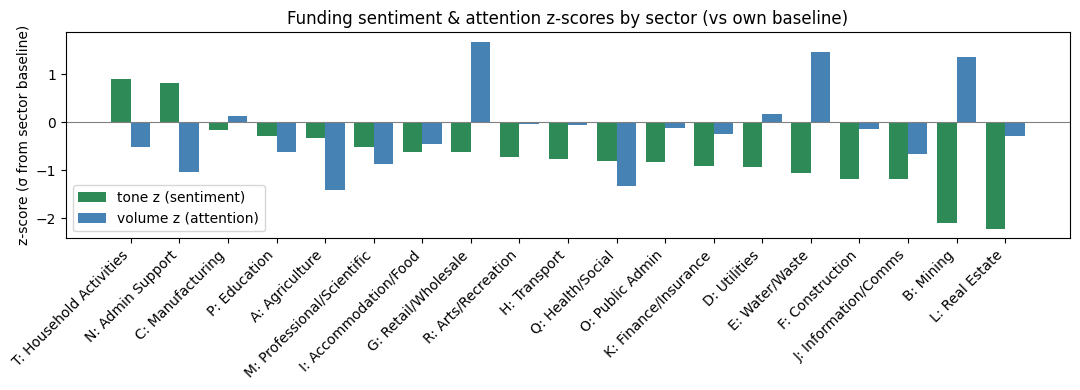

In [ ]:
# ===========================================================================
# BigQuery version — ALL sectors in one query, true article counts, baseline z
# ===========================================================================
# --- dev / cost controls (protect your 1 TB/month free tier) ---------------
USE_CACHE = True  # if a cache file exists, load it (0 GB) instead of querying
DEV_MODE  = False    # True -> tiny 4-week window for a cheap real-data smoke test

# Workflow: leave USE_CACHE=True to iterate the z-score/plot for free on cached data.
# Set USE_CACHE=False once to pull fresh data (it overwrites the cache).
# Use DEV_MODE=True for a ~13 GB smoke test; False = full ~174 GB / 53-week run.
# ---------------------------------------------------------------------------
import os

# A row can match several sectors (sectors overlap) — that's expected.
# Sector matching is on V2Themes theme-NAMES (approximate; refine vs LOOKUP-GKGTHEMES).
# Sector taxonomy = the 21 Companies House SIC SECTIONS (A-U), so these media
# z-scores key by the SAME labels build_panel()'s code_to_section() assigns to
# companies -> the media join stops missing on unmapped sectors. Patterns are GDELT
# V2Themes theme-NAME substrings (approximate; refine vs LOOKUP-GKGTHEMES). Sections
# O/T/U rarely appear in funding news -> expect thin cells (sector-only fallback).
SECTOR_PATTERNS = {                          # SIC section -> theme-name regex (lowercase)
    "A: Agriculture":              "agricultur|farming|forestry|fishing|crop|livestock",
    "B: Mining":                   "mining|quarry|coal|petroleum|extraction",
    "C: Manufacturing":            "manufactur|industrial|factory",
    "D: Utilities":                "electricity|power|energy|utilit|renewable",
    "E: Water/Waste":              "water|sewage|waste|recycling",
    "F: Construction":             "construction|infrastructure|building",
    "G: Retail/Wholesale":         "retail|wholesale|consumer goods",
    "H: Transport":                "transport|logistic|freight|shipping|aviation|railway",
    "I: Accommodation/Food":       "hospitality|tourism|restaurant|hotel|catering",
    "J: Information/Comms":         "telecom|software|information technology|media|internet",
    "K: Finance/Insurance":        "bank|financ|insurance|fintech",
    "L: Real Estate":              "real estate|property|housing",
    "M: Professional/Scientific":  "consulting|legal|accounting|engineering|research|scientific",
    "N: Admin Support":            "recruitment|staffing|outsourcing|facilities",
    "O: Public Admin":             "government|public administration|defence",
    "P: Education":                "education|school|university|training",
    "Q: Health/Social":            "health|social care|hospital|pharma",
    "R: Arts/Recreation":          "arts|entertainment|sport|recreation|gambling",
    "S: Other Services":           "repair|personal service|membership",
    "T: Household Activities":     "household|domestic",
    "U: Extraterritorial":         "international organization|diplomatic",
}
FUNDING_PAT = "fund|investment|financ|lend|loan|subsidy|grant|capital"


def _safe_pat(p):                           # allow only word chars, spaces, '|'
    assert re.fullmatch(r"[a-z0-9 |]+", p), f"unsafe pattern: {p!r}"
    return p


_sector_cte = " UNION ALL ".join(
    f"SELECT '{name}' AS sector, r'{_safe_pat(pat)}' AS pat"
    for name, pat in SECTOR_PATTERNS.items())

# Baseline length drives scan cost: ~3.3 GB/week of GKG text columns.
#   4 wk (dev) ≈ 13 GB  |  26 wk (~6 mo) ≈ 85 GB  |  53 wk (~1 yr) ≈ 174 GB.
BASE_WEEKS = 4 if DEV_MODE else 104
bq_start = END_D - dt.timedelta(weeks=BASE_WEEKS)
CACHE_DIR  = GDELT_CACHE                      # from paths.py, not cwd
CACHE_DIR.mkdir(parents=True, exist_ok=True)
CACHE_FILE = CACHE_DIR / f"sector_weekly_cache_{BASE_WEEKS}w.parquet"  # window-specific cache

# We also count DISTINCT days per week so volume can be read as articles/day.
# That matters because the CURRENT week is usually partial (fewer days), which
# would drag a raw weekly count — and its volume z-score — artificially low.
sql_sector = f"""
WITH sectors AS ( {_sector_cte} ),
matched AS (
  SELECT
    s.sector,
    PARSE_DATE('%Y%m%d', SUBSTR(CAST(g.DATE AS STRING), 1, 8)) AS day,
    DATE_TRUNC(PARSE_DATE('%Y%m%d', SUBSTR(CAST(g.DATE AS STRING), 1, 8)), WEEK) AS week,
    SAFE_CAST(SPLIT(g.V2Tone, ',')[SAFE_OFFSET(0)] AS FLOAT64) AS tone
  FROM {GKG} g
  CROSS JOIN sectors s
  WHERE g._PARTITIONTIME >= TIMESTAMP(@pstart) AND g._PARTITIONTIME < TIMESTAMP(@pend)
    AND g.DATE >= @dstart AND g.DATE <= @dend
    AND g.V2Locations LIKE '%#UK#%'
    AND REGEXP_CONTAINS(LOWER(g.V2Themes), r'{_safe_pat(FUNDING_PAT)}')
    AND REGEXP_CONTAINS(LOWER(g.V2Themes), s.pat)
)
SELECT sector, week, COUNT(*) AS articles, COUNT(DISTINCT day) AS days, AVG(tone) AS avg_tone
FROM matched
GROUP BY sector, week
ORDER BY sector, week
"""

# Free re-runs: load the cache if present; otherwise query (dry-run guarded) + cache.
if USE_CACHE and CACHE_FILE.exists():
    weekly = pd.read_parquet(CACHE_FILE)
    print(f"Loaded {len(weekly)} rows from cache '{CACHE_FILE}' (0 GB scanned). "
          "Set USE_CACHE=False to pull fresh data.")
else:
    weekly = bq_query(sql_sector, params=date_params(bq_start, END_D), max_gb=400.0)
    weekly.to_parquet(CACHE_FILE)
    print(f"Queried BigQuery and cached {len(weekly)} rows -> '{CACHE_FILE}'.")

# Volume measure for the z-score = articles PER DAY (partial-week-safe).
# A z-score is scale-invariant, so per-day == per-week for full weeks; it only
# differs for the partial current week, which is exactly the bias we remove.
if "days" in weekly.columns:
    weekly["vol"] = weekly["articles"] / weekly["days"].clip(lower=1)
else:                                       # older cache (no day count) -> raw count
    weekly["vol"] = weekly["articles"]
    print("NOTE: this cache predates the per-day volume fix, so vol_z uses raw "
          "weekly counts — the latest (partial) week will read low. Re-pull with "
          "USE_CACHE=False for partial-week-safe volume z-scores.")

# Two z-scores per sector, each vs the sector's OWN baseline (so both compare
# across sectors): tone_z = is sentiment unusually positive? vol_z = is the
# sector getting unusually much coverage? Strongest lead = high on both.
MIN_ARTICLES, MIN_WEEKS = 25, 12           # min-article floor + enough baseline weeks
out = []
for sec, d in weekly.groupby("sector"):
    d = d.sort_values("week")
    latest, base = d.iloc[-1], d.iloc[:-1]      # latest week vs its own prior weeks
    enough = len(base) >= MIN_WEEKS and latest["articles"] >= MIN_ARTICLES
    tsd = base["avg_tone"].std(ddof=0)          # tone spread over the baseline
    vsd = base["vol"].std(ddof=0)               # volume (articles/day) spread
    tone_z = ((latest["avg_tone"] - base["avg_tone"].mean()) / tsd
              if enough and tsd and tsd > 0 else float("nan"))
    vol_z  = ((latest["vol"] - base["vol"].mean()) / vsd
              if enough and vsd and vsd > 0 else float("nan"))
    out.append({
        "sector": sec, "latest_week": latest["week"],
        "latest_articles": int(latest["articles"]),
        "latest_tone": round(float(latest["avg_tone"]), 2),
        "baseline_tone": round(float(base["avg_tone"].mean()), 2) if len(base) else float("nan"),
        "baseline_artic_day": round(float(base["vol"].mean()), 1) if len(base) else float("nan"),
        "tone_z": round(float(tone_z), 2) if tone_z == tone_z else float("nan"),
        "vol_z":  round(float(vol_z), 2)  if vol_z  == vol_z  else float("nan"),
    })
ranked_bq = (pd.DataFrame(out).sort_values("tone_z", ascending=False, na_position="last")
             .reset_index(drop=True))
print("\nBigQuery — sector funding sentiment & attention, most improved this week (z-scores):\n")
print(ranked_bq.to_string(index=False))

# Grouped bars: tone z (sentiment) beside volume z (attention) per sector.
r = ranked_bq.dropna(subset=["tone_z"])
if not r.empty:
    xs = list(range(len(r)))
    w = 0.4
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.bar([i - w / 2 for i in xs], r["tone_z"], width=w,
           label="tone z (sentiment)", color="seagreen")
    ax.bar([i + w / 2 for i in xs], r["vol_z"].fillna(0), width=w,
           label="volume z (attention)", color="steelblue")
    ax.axhline(0, color="grey", lw=0.8)
    ax.set_xticks(xs)
    ax.set_xticklabels(r["sector"], rotation=45, ha="right")
    ax.set_ylabel("z-score (σ from sector baseline)")
    ax.set_title("Funding sentiment & attention z-scores by sector (vs own baseline)")
    ax.legend()
    plt.tight_layout(); plt.show()

## 3 · The sector × region weekly index (`tone_z`, `vol_z`)

This wires **Part 3** (all sectors, one scan) and **Query B** (`V2Locations` → UK-region rollup)
together into the project's deliverable: a weekly **(sector group, UK region)** media index that
joins to each firm by **(SIC group, region, cutoff week)**. Region is what gives the feature signal
**within** a gated single-sector lead list — every firm on that list shares the sector score, so the
regional variation is what differentiates them.

**Design points:**

- **One aggregated query**, `GROUP BY sector, region, week`. BigQuery bills by **bytes scanned**
  (columns × days), not by cells or queries, so adding region as a dimension costs ~nothing extra —
  never loop per cell.
- **Point-in-time z-scores, every week** — not just the latest. Each (sector, region, week) cell is
  scored against its **own trailing baseline** (up to 52 weeks) that **ends the week before**, so a
  value joined at a firm's cutoff week never sees the future. (With the default 26-week cache the
  trailing window is shorter; re-pull with `BASE_WEEKS = 53` for the full 52-week baseline.)
- **Thin cells fall back to sector-only.** Splitting by ~12 regions thins each cell; where a cell has
  fewer than `MIN_CELL_ARTICLES` in the week (or no usable baseline), the row takes the **sector-only
  z** from Part 3's data instead. A `z_source` column records which was used.
- **Regions stay coarse** — the same ~12 ITL1-style regions as `CITY_TO_REGION` (cities would thin
  cells into uselessness).

**Output** (also cached to Parquet): `media_index` with columns
`sector · region · week · articles · tone_z · vol_z · z_source` — ready to merge onto the
point-in-time company feature table.

**Two roles downstream:** (1) *context feature* — `tone_z` / `vol_z` joined per firm in training and
scoring; (2) the *sector gate* at scoring time still comes from Part 3's sector-level ranking.

> 💰 **Cost switch — `USE_CACHE_REGION` (this cell's own, separate from Part 3's `USE_CACHE`).**
> This is a **second ~180 GB scan**, distinct from Part 3's. It has its own switch on purpose: setting
> Part 3's `USE_CACHE=False` to refresh the sector data will **not** silently re-pull this region
> query. Leave `USE_CACHE_REGION=True` to reload the cached Parquet (0 GB); flip it to `False` only
> when you deliberately want to (re)build the region cache. The dry-run guard still applies either way.

⚠️ Run the Part 3 cell first — this cell reuses its config, its `weekly` data (for the fallback), and
its `BASE_WEEKS` / `DEV_MODE` settings.

Loaded 18303 rows from cache '/Users/natchalin_/Projects/final_project/Lloyds/API/GDELT/BigQuery Cache files/sector_region_weekly_cache_104w.parquet' (0 GB scanned). Set USE_CACHE_REGION=False to pull fresh data.

Context-media index: 20339 (sector, region, week) rows -> '/Users/natchalin_/Projects/final_project/Lloyds/API/GDELT/BigQuery Cache files/context_media_index_104w.parquet'
Feature-table join key: (SIC group -> sector, region, cutoff week).
Sector-only fallback used on 52% of rows (a cell needs >= 10 articles and a >= 12-week baseline).


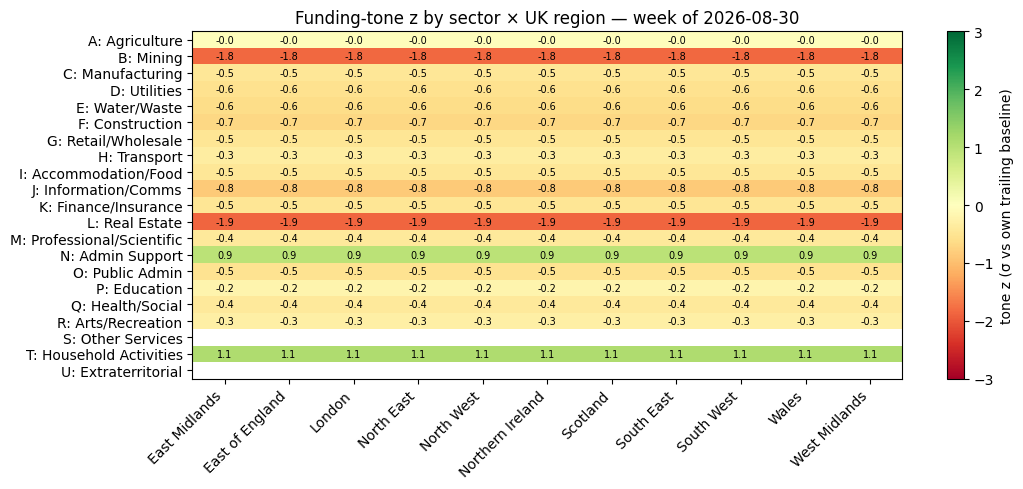

In [11]:
# ===========================================================================
# Part 4 — sector × region × week context-media index (joinable feature table)
# ===========================================================================
# Extends Part 3's single scan with Query B's V2Locations region rollup:
# GROUP BY sector, region, week in ONE aggregated query. BigQuery bills bytes
# scanned (columns × days), so the extra GROUP BY dimension is ~free — never
# loop per cell.
# Depends on the Part 3 cell (SECTOR_PATTERNS/_sector_cte, _safe_pat,
# FUNDING_PAT, BASE_WEEKS, bq_start, MIN_WEEKS, and `weekly` for the
# sector-only fallback) — run Part 3 first.
import numpy as np

# --- Part 4's OWN cache switch (independent of Part 3's USE_CACHE) ----------
# This is a SEPARATE ~180 GB scan from Part 3. Keeping its own switch means
# flipping Part 3's USE_CACHE=False to refresh the sector data does NOT also
# silently re-pull this region query. Set THIS to False only when you
# deliberately want to (re)build the region cache.
USE_CACHE_REGION = True   # True -> load the region Parquet (0 GB) if it exists

MIN_CELL_ARTICLES = 10   # region split thins cells; below this -> sector-only fallback
MAX_BASE_WEEKS    = 52   # trailing-baseline cap (fully used only once BASE_WEEKS=53)
CACHE_DIR    = GDELT_CACHE                    # from paths.py, not cwd
CACHE_DIR.mkdir(parents=True, exist_ok=True)
REGION_CACHE = CACHE_DIR / f"sector_region_weekly_cache_{BASE_WEEKS}w.parquet"
INDEX_FILE   = CACHE_DIR / f"context_media_index_{BASE_WEEKS}w.parquet"

for _c in CITY_TO_REGION:                    # city names are interpolated into SQL
    assert re.fullmatch(r"[A-Za-z ]+", _c), f"unsafe city name: {_c!r}"
_region_cte = " UNION ALL ".join(
    f"SELECT '{c}' AS city, '{r}' AS region" for c, r in CITY_TO_REGION.items())

# Same filters as Part 3, plus: unnest V2Locations, keep UK city/ADM1 mentions,
# map city -> region in SQL. DISTINCT on GKGRECORDID so an article naming two
# cities in the SAME region counts once there (it can still appear in several
# regions/sectors — intended). Articles with only a country-level UK mention
# carry no region: absent here, but still inside Part 3's sector totals, which
# is exactly what the sector-only fallback is built from.
sql_cells = f"""
WITH sectors AS ( {_sector_cte} ),
regions AS ( {_region_cte} ),
matched AS (
  SELECT DISTINCT
    s.sector,
    r.region,
    g.GKGRECORDID AS id,
    PARSE_DATE('%Y%m%d', SUBSTR(CAST(g.DATE AS STRING), 1, 8)) AS day,
    DATE_TRUNC(PARSE_DATE('%Y%m%d', SUBSTR(CAST(g.DATE AS STRING), 1, 8)), WEEK) AS week,
    SAFE_CAST(SPLIT(g.V2Tone, ',')[SAFE_OFFSET(0)] AS FLOAT64) AS tone
  FROM {GKG} g
  CROSS JOIN sectors s
  CROSS JOIN UNNEST(SPLIT(g.V2Locations, ';')) AS loc
  JOIN regions r
    ON r.city = TRIM(SPLIT(SPLIT(loc, '#')[SAFE_OFFSET(1)], ',')[SAFE_OFFSET(0)])
  WHERE g._PARTITIONTIME >= TIMESTAMP(@pstart) AND g._PARTITIONTIME < TIMESTAMP(@pend)
    AND g.DATE >= @dstart AND g.DATE <= @dend
    AND SPLIT(loc, '#')[SAFE_OFFSET(2)] = 'UK'
    AND SAFE_CAST(SPLIT(loc, '#')[SAFE_OFFSET(0)] AS INT64) >= 3
    AND REGEXP_CONTAINS(LOWER(g.V2Themes), r'{_safe_pat(FUNDING_PAT)}')
    AND REGEXP_CONTAINS(LOWER(g.V2Themes), s.pat)
)
SELECT sector, region, week,
       COUNT(DISTINCT id) AS articles,
       COUNT(DISTINCT day) AS days,
       AVG(tone) AS avg_tone
FROM matched
GROUP BY sector, region, week
ORDER BY sector, region, week
"""

# Scan cost ≈ Part 3 + the small GKGRECORDID column. 26 wk ≈ ~90 GB; a full
# 53-wk pull (the target 52-week baseline) ≈ ~180 GB — hence max_gb=200.
# USE_CACHE_REGION (this cell's own switch) gates the scan — NOT Part 3's USE_CACHE.
if USE_CACHE_REGION and REGION_CACHE.exists():
    cells = pd.read_parquet(REGION_CACHE)
    print(f"Loaded {len(cells)} rows from cache '{REGION_CACHE}' (0 GB scanned). "
          "Set USE_CACHE_REGION=False to pull fresh data.")
else:
    cells = bq_query(sql_cells, params=date_params(bq_start, END_D), max_gb=450.0)
    cells.to_parquet(REGION_CACHE)
    print(f"Queried BigQuery and cached {len(cells)} rows -> '{REGION_CACHE}'.")

cells["week"]  = pd.to_datetime(cells["week"])
weekly["week"] = pd.to_datetime(weekly["week"])
cells["vol"]   = cells["articles"] / cells["days"].clip(lower=1)  # partial-week-safe


def trailing_z(s, window=MAX_BASE_WEEKS, min_weeks=MIN_WEEKS):
    """Point-in-time z: each week vs the <=52 trailing weeks that END the week before."""
    base = s.shift(1)                        # baseline excludes the scored week itself
    mean = base.rolling(window, min_periods=min_weeks).mean()
    std  = base.rolling(window, min_periods=min_weeks).std(ddof=0)
    return (s - mean) / std.replace(0, np.nan)


# Complete each series over the full week grid: a missing week = zero coverage
# (real volume signal, so vol=0); tone stays NaN (no articles -> no tone).
all_weeks = pd.date_range(weekly["week"].min(), weekly["week"].max(), freq="7D")


def complete_and_z(g):
    g = g.set_index("week").reindex(all_weeks)
    g.index.name = "week"
    g["articles"] = g["articles"].fillna(0).astype(int)
    g["vol"]      = g["vol"].fillna(0.0)
    g["tone_z"]   = trailing_z(g["avg_tone"])
    g["vol_z"]    = trailing_z(g["vol"])
    return g.reset_index()


# 1) per-(sector, region) cell z-scores — every week, not just the latest,
#    because the training table joins at each firm's cutoff week.
frames = []
for (sec, reg), g in cells.groupby(["sector", "region"]):
    z = complete_and_z(g)
    z["sector"], z["region"] = sec, reg
    frames.append(z)
cell_z = pd.concat(frames, ignore_index=True)

# 2) sector-only z-scores from Part 3's `weekly` = the thin-cell fallback
sframes = []
for sec, g in weekly.groupby("sector"):
    z = complete_and_z(g)[["week", "tone_z", "vol_z"]]
    z.columns = ["week", "tone_z_sector", "vol_z_sector"]
    z["sector"] = sec
    sframes.append(z)
sector_z = pd.concat(sframes, ignore_index=True)

# 3) fall back where the cell is thin (few articles) or lacks a usable baseline
idx = cell_z.merge(sector_z, on=["sector", "week"], how="left")
thin = idx["tone_z"].isna() | (idx["articles"] < MIN_CELL_ARTICLES)
idx["z_source"] = np.where(thin, "sector-fallback", "cell")
idx["tone_z"]   = idx["tone_z"].where(~thin, idx["tone_z_sector"])
idx["vol_z"]    = idx["vol_z"].where(~thin, idx["vol_z_sector"])

media_index = (idx[["sector", "region", "week", "articles", "tone_z", "vol_z", "z_source"]]
               .dropna(subset=["tone_z", "vol_z"], how="all")
               .sort_values(["week", "sector", "region"]).reset_index(drop=True))
media_index.to_parquet(INDEX_FILE, index=False)

fb = (media_index["z_source"] == "sector-fallback").mean()
print(f"\nContext-media index: {len(media_index)} (sector, region, week) rows -> '{INDEX_FILE}'")
print("Feature-table join key: (SIC group -> sector, region, cutoff week).")
print(f"Sector-only fallback used on {fb:.0%} of rows (a cell needs >= "
      f"{MIN_CELL_ARTICLES} articles and a >= {MIN_WEEKS}-week baseline).")

# Latest-week heatmap. Within a gated single-sector list it's the REGION
# variation (one row here) that differentiates firms — that's the signal.
latest_week = media_index["week"].max()
pv = (media_index[media_index["week"] == latest_week]
      .pivot(index="sector", columns="region", values="tone_z"))
if not pv.empty:
    fig, ax = plt.subplots(figsize=(11, 5))
    im = ax.imshow(pv.values.astype(float), cmap="RdYlGn", vmin=-3, vmax=3, aspect="auto")
    ax.set_xticks(range(len(pv.columns)))
    ax.set_xticklabels(pv.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(pv.index)))
    ax.set_yticklabels(pv.index)
    for i in range(pv.shape[0]):
        for j in range(pv.shape[1]):
            v = pv.values[i, j]
            if v == v:                       # skip NaN cells
                ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=7)
    fig.colorbar(im, ax=ax, label="tone z (σ vs own trailing baseline)")
    ax.set_title(f"Funding-tone z by sector × UK region — week of {latest_week.date()}")
    plt.tight_layout(); plt.show()

In [12]:
import os
import pandas as pd
import sys
from pathlib import Path
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "paths.py").is_file()), None)
sys.path.insert(0, str(ROOT))
from paths import MEDIA_INDEX
media_index = pd.read_parquet(MEDIA_INDEX)
media_index[["sector", "region", "week", "tone_z", "vol_z"]]

,sector,region,week,tone_z,vol_z
0,A: Agriculture,East Midlands,2024-11-24,1.478515,5.194651
1,A: Agriculture,East of England,2024-11-24,1.025038,-1.269597
2,A: Agriculture,London,2024-11-24,-1.669141,0.66253
3,A: Agriculture,North East,2024-11-24,-0.829129,0.282027
4,A: Agriculture,North West,2024-11-24,0.132000,-0.685926
...,...,...,...,...,...
20334,T: Household Activities,South East,2026-08-30,1.092288,-0.351942
20335,T: Household Activities,South West,2026-08-30,1.092288,-0.351942
20336,T: Household Activities,Wales,2026-08-30,1.092288,-0.351942
20337,T: Household Activities,West Midlands,2026-08-30,1.092288,-0.351942


## 4 · Company postcode → region (the join key on the company side)

Derives each firm's **region** from its **registered-office postcode** using
**[postcodes.io](https://postcodes.io)** (free, keyless, bulk ≤100/call) and writes two columns into
the CH-pipeline SME file `com_names_sme_test.csv`:

- **`town_api`** — the postcode's local-authority district (postcodes.io `admin_district`).
- **`region`** — mapped onto the **exact same 12 labels as `CITY_TO_REGION`** so it joins straight to
  the media index.

**Postcode backfill (built in).** After the CH-pipeline expansion, the *new* companies carry
`post_code` from their raw file, but the **original ~13.5k** do not (their raw files had none). This
cell first backfills their `post_code` — **free, no API** — from the earlier
`11_7_26_with_context_media.csv` (matched on `com_num`), so region is derived uniformly for the whole
population. Then bulk postcodes.io + a small **outcode fallback** for terminated/large-user postcodes.

**Region mapping.** England → ONS `region` (renaming `"Yorkshire and The Humber"` → `"Yorkshire"`);
Scotland / Wales / Northern Ireland → `country`.

> 🔁 **Idempotent:** with `FORCE_REFRESH = False` the cell skips the API entirely once `town_api` /
> `region` exist. Flip to `True` to re-pull.

⚠️ `region` is the **registered-office** region — the point-in-time location you join on.

In [13]:
# ===========================================================================
# Part 5 — enrich the SME company table with town + GDELT region (postcodes.io)
# ===========================================================================
# Adds two columns to the SME table so it can join to the Part 4 media index:
#   town_api : local-authority town from the postcode (postcodes.io admin_district)
#   region   : mapped onto the SAME 12 labels as CITY_TO_REGION / media_index
# postcodes.io is free & keyless; the bulk endpoint resolves <=100 postcodes/call.
# ROW-INCREMENTAL: resolves only rows still missing `region`, so re-running fills
# gaps (e.g. companies whose post_code was just backfilled) instead of skipping.
import time
import requests
import pandas as pd
from pathlib import Path

# The CH-pipeline SME file (post-expansion). New companies carry post_code from
# their raw file; the ORIGINAL ~13.5k companies do not (their raw files had none),
# so we backfill those from the earlier context-media file before deriving region.
# --- portable paths: resolve the project root from ANY working directory ---
import sys
from pathlib import Path
_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
              if (p / "paths.py").is_file()), None)
if _ROOT is None:
    raise RuntimeError(
        "Cannot find paths.py in any parent of "
        f"{Path.cwd()} — run this notebook from inside the project folder.")
sys.path.insert(0, str(_ROOT))
from paths import COMPANIES_CSV, POSTCODE_BACKFILL_SRC

COMPANY_CSV = str(COMPANIES_CSV)    # the single CH company table (is_sme flags the population)
POSTCODE_BACKFILL_SRC = str(POSTCODE_BACKFILL_SRC)
FORCE_REFRESH = False   # True -> re-resolve region for EVERY row, not just the missing ones

# postcodes.io 'region' is England-only (ONS ITL1); Scotland/Wales/NI come via
# 'country'. Normalise BOTH onto the 12 GDELT labels (CITY_TO_REGION values) so
# the column is directly joinable to the media index.
COUNTRY_AS_REGION = {"Scotland", "Wales", "Northern Ireland"}
REGION_RENAME = {"Yorkshire and The Humber": "Yorkshire"}   # match the GDELT label


def _to_gdelt_region(region, country):
    """Map a postcodes.io (region, country) pair onto a GDELT region label."""
    if country in COUNTRY_AS_REGION:
        return country
    if region is None:
        return None
    return REGION_RENAME.get(region, region)     # England ONS names already align


def resolve_postcodes(postcodes, chunk=100, pause=0.15, session=None):
    """Bulk-resolve UK postcodes -> {postcode: (town, region)} via postcodes.io."""
    s = session or requests.Session()
    out = {}
    for i in range(0, len(postcodes), chunk):
        batch = postcodes[i:i + chunk]
        for attempt in range(4):
            try:
                r = s.post("https://api.postcodes.io/postcodes",
                           json={"postcodes": batch}, timeout=30)
                r.raise_for_status()
                break
            except requests.RequestException:
                if attempt == 3:
                    raise
                time.sleep(2 ** attempt)         # backoff on transient errors
        for item in r.json()["result"]:
            res = item["result"]
            out[item["query"]] = ((res.get("admin_district"),
                                   _to_gdelt_region(res.get("region"), res.get("country")))
                                  if res else (None, None))
        print(f"  resolved {min(i + chunk, len(postcodes))}/{len(postcodes)}", end="\r")
        time.sleep(pause)                        # be polite to the free API
    print()
    return out


def resolve_via_outcode(postcodes, district_to_region, session=None, pause=0.1):
    """Fallback for terminated / large-user postcodes: outcode -> (town, region)."""
    s = session or requests.Session()
    out = {}
    for p in postcodes:
        outcode = p.split(" ")[0]
        try:
            r = s.get(f"https://api.postcodes.io/outcodes/{outcode}", timeout=30)
        except requests.RequestException:
            continue
        if r.status_code != 200:
            continue
        res = r.json().get("result") or {}
        dists = res.get("admin_district") or []
        ctys  = res.get("country") or []
        town = dists[0] if dists else None
        country = ctys[0] if ctys else None
        region = (country if country in COUNTRY_AS_REGION
                  else next((district_to_region[d] for d in dists
                             if d in district_to_region), None))
        out[p] = (town, region)
        time.sleep(pause)
    return out


df = pd.read_csv(COMPANY_CSV, dtype=str, low_memory=False)

# The table now holds non-SME companies too (the do-not-re-pull cache). Resolve
# postcodes only for the modelling population — but every write below keeps the
# FULL frame, or we would silently delete 154k cached rows.
_is_sme = (df["is_sme"].astype(str).str.lower().eq("true")
           if "is_sme" in df.columns else pd.Series(True, index=df.index))
for col in ("post_code", "town_api", "region"):
    if col not in df.columns:
        df[col] = pd.NA

# --- 1) backfill post_code for the ORIGINAL companies (their raw files had none) --
# Free (no API): pull post_code from the earlier context-media file, matched on
# com_num, so region can be derived for the whole expanded population.
need_pc = df["post_code"].fillna("").str.strip() == ""
if need_pc.any() and Path(POSTCODE_BACKFILL_SRC).exists():
    src = (pd.read_csv(POSTCODE_BACKFILL_SRC, dtype=str)
             .drop_duplicates("com_num").set_index("com_num")["post_code"])
    df.loc[need_pc, "post_code"] = df.loc[need_pc, "com_num"].map(src)
    got = int(df.loc[need_pc, "post_code"].notna().sum())
    print(f"backfilled post_code for {got}/{int(need_pc.sum())} companies "
          f"from '{Path(POSTCODE_BACKFILL_SRC).name}'")
elif need_pc.any():
    print(f"WARNING: {int(need_pc.sum())} companies lack post_code and the backfill "
          f"source was not found at '{POSTCODE_BACKFILL_SRC}' — check the path/cwd.")

# --- 2) resolve region for rows that still lack it (incremental & self-healing) ---
pc_key = df["post_code"].fillna("").str.strip().str.upper()
need = ((pc_key != "") if FORCE_REFRESH else (df["region"].isna() & (pc_key != ""))) & _is_sme
to_resolve = sorted(set(pc_key[need]) - {""})

if not to_resolve:
    print(f"region already complete — nothing to resolve "
          f"({df['region'].notna().sum()}/{len(df)} filled). "
          "Set FORCE_REFRESH=True to re-pull everything.")
else:
    print(f"Resolving {len(to_resolve)} unique postcodes via postcodes.io "
          f"(for {int(need.sum())} companies missing region) ...")
    mapping = resolve_postcodes(to_resolve)
    df.loc[need, "town_api"] = pc_key[need].map(lambda p: mapping.get(p, (None, None))[0])
    df.loc[need, "region"]   = pc_key[need].map(lambda p: mapping.get(p, (None, None))[1])

    # outcode fallback for postcodes the live endpoint couldn't resolve
    miss = df["region"].isna() & (pc_key != "") & _is_sme
    miss_pc = sorted(set(pc_key[miss]))
    if miss_pc:
        d2r = (df.dropna(subset=["town_api", "region"])
                 .drop_duplicates("town_api").set_index("town_api")["region"].to_dict())
        print(f"Outcode fallback for {len(miss_pc)} unresolved postcodes ...")
        fill = resolve_via_outcode(miss_pc, d2r)
        for i in df.index[miss]:
            town, region = fill.get(pc_key[i], (None, None))
            if pd.isna(df.at[i, "town_api"]) and town:
                df.at[i, "town_api"] = town
            if pd.isna(df.at[i, "region"]) and region:
                df.at[i, "region"] = region

    df.to_csv(COMPANY_CSV, index=False)
    print(f"Wrote '{COMPANY_CSV}' with town_api + region.")

# --- summary (runs either way) ---------------------------------------------
pc_present = df["post_code"].fillna("").str.strip() != ""
print(f"\nregion filled (is_sme rows): {df.loc[_is_sme, 'region'].notna().sum()}/{int(_is_sme.sum())}  "
      f"(blank postcode: {(~pc_present).sum()}; "
      f"unresolved w/ postcode: {(df['region'].isna() & pc_present).sum()})")
print("\nCompanies per GDELT region:")
print(df["region"].value_counts(dropna=False).to_string())

backfilled post_code for 0/11913 companies from '11_7_26_with_context_media.csv'
Resolving 140 unique postcodes via postcodes.io (for 142 companies missing region) ...
  resolved 140/140
Outcode fallback for 140 unresolved postcodes ...
Wrote '/Users/natchalin_/Projects/final_project/Lloyds/API/CompaniesHouse/company_data/companies.csv' with town_api + region.

region filled (is_sme rows): 567421/567960  (blank postcode: 11913; unresolved w/ postcode: 260088)

Companies per GDELT region:
region
NaN                 272001
London              149435
South East           83883
East of England      57653
North West           56526
West Midlands        43700
South West           42006
Yorkshire            35299
East Midlands        33327
Scotland             29029
Wales                15328
North East           12721
Northern Ireland      8514


## 5 · The weekly sector gate

Takes the current week and a scored lead list, and returns the leads re-ordered so that firms in
media-active sectors surface first.

Three deliberate design choices, each from the evidence above:

- **`vol_z` only** — `tone_z` showed a 1.00× lift (no signal at all).
- **Soft re-rank, not a hard filter** — the timing effect is not significant, so dropping leads from
  quiet sectors would discard proven-good firms on the basis of noise. Every lead is kept; only the
  order changes, and `GATE_WEIGHT` controls how much.
- **Top-N sectors, never the single hottest cell** — 21 sectors × 11 regions = 231 cells, so the
  weekly maximum is mostly sampling noise. Aggregating to sector level and taking a handful is far
  more stable.

In [14]:
import os
import pandas as pd

GATE_WEIGHT = 0.15      # how far the gate may move a lead (0 = ignore gate, 1 = gate dominates)
TOP_SECTORS = 5         # how many sectors count as "hot" in a given week


def hot_sectors(media_index, week=None, top_n=TOP_SECTORS):
    """Sectors with the most elevated news VOLUME in `week`.

    Aggregates vol_z across regions (231 cells -> 21 sectors) because a single
    sector x region cell's weekly max is mostly noise. Snaps to the most recent
    index week at or before `week`, so it is safe to call with today's date.
    """
    mi = media_index.copy()
    mi["week"] = pd.to_datetime(mi["week"])
    week = pd.Timestamp(week or pd.Timestamp.today().normalize())
    prior = mi.loc[mi["week"] <= week, "week"]
    if prior.empty:
        raise ValueError(f"media index has no week on/before {week.date()}")
    use = prior.max()
    s = (mi[mi["week"] == use].groupby("sector")["vol_z"].mean()
           .sort_values(ascending=False))
    return use, s.head(top_n), s


def apply_gate(leads, media_index, week=None, score_col="score",
               weight=GATE_WEIGHT, top_n=TOP_SECTORS):
    """Re-rank a scored lead list by this week's sector media activity.

    `leads` needs a `sector` column and a model score. Returns a copy with
    `sector_vol_z`, `is_hot_sector` and `gated_score`, sorted best-first.
    Nothing is dropped — only the ordering changes.
    """
    use_week, top, all_s = hot_sectors(media_index, week, top_n)
    out = leads.copy()
    out["sector_vol_z"]  = out["sector"].map(all_s).fillna(0.0)
    out["is_hot_sector"] = out["sector"].isin(top.index).astype(int)

    # rank-normalise both to 0-1 so the blend is scale-free
    r_score = out[score_col].rank(pct=True)
    r_media = out["sector_vol_z"].rank(pct=True)
    out["gated_score"] = (1 - weight) * r_score + weight * r_media

    out = out.sort_values("gated_score", ascending=False).reset_index(drop=True)
    print(f"gate week {use_week.date()} (weight {weight})  hot sectors:")
    print(top.round(2).to_string())
    return out


# --- demo on the cached index (no model needed) ------------------------------
import sys
from pathlib import Path
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "paths.py").is_file()), None)
sys.path.insert(0, str(ROOT))
from paths import MEDIA_INDEX
_mi = pd.read_parquet(MEDIA_INDEX)
_wk, _top, _ = hot_sectors(_mi)
print(f"most recent index week: {_wk.date()}\n")
print("this week's hot sectors (mean vol_z across regions):")
print(_top.round(2).to_string())

most recent index week: 2026-08-30

this week's hot sectors (mean vol_z across regions):
sector
G: Retail/Wholesale    2.24
B: Mining              1.35
E: Water/Waste         1.21
C: Manufacturing        0.8
D: Utilities           0.15
